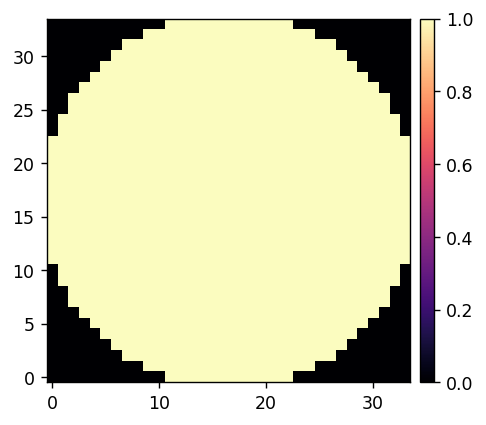

In [68]:
import numpy as np
import astropy.units as u
import threading as th
import time 
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from importlib import reload
import copy
import os
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import scoob_llowfsc
from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc import utils
from scoob_llowfsc import dm
from scoob_llowfsc import telem
import scoob_llowfsc.scoob_interface as scoobi
from scoob_llowfsc import llowfsc

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient
client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()
    client = IndiClient()
    client.connect()
    client.get_properties()

wavelength = 633e-9

wavelength_c = 633e-9
camsci_pxscl = 4.6e-6
camsci_pxscl_lamDc = 0.307

dm_mask = ensure_np_array(dm.make_mask(34))
utils.imshow([dm_mask])

data_path = scoob_llowfsc.path/'exp-data'


# Setup SHMIM names and directory paths.

In [70]:
camsci_name = 'camlo'
camlo_name = 'camsci'
dm_lo_name = 'dm00disp02'
dm_ho_name = 'dm00disp03'

camlo_ref_name = 'camlo_ref_0'
camlo_ref_offset_name = 'camlo_ref_offset'

camsci_rawims_path = Path(f'/opt/MagAOX/rawimages/{camsci_name}/')
camlo_rawims_path = Path(f'/opt/MagAOX/rawimages/{camlo_name}/')
camlo_ref_rawims_path = Path(f'/opt/MagAOX/rawimages/{camlo_ref_name}/')
camlo_ref_offset_rawims_path = Path(f'/opt/MagAOX/rawimages/{camlo_ref_offset_name}/')
dm_lo_rawims_path = Path(f'/opt/MagAOX/rawimages/{dm_lo_name}/')
dm_ho_rawims_path = Path(f'/opt/MagAOX/rawimages/{dm_ho_name}/')

# date = 20250409
# date = 20250410
date = today
exp_path = data_path/f'exp-{date}'
llowfsc_data_path = data_path/f'exp-{today}'/'llowfsc'
llowfsc_telem_path = llowfsc_data_path/'raw-telem'
llowfsc_unpacked_path = llowfsc_data_path/'unpacked-telem'


In [71]:
telem.make_dir(exp_path)
telem.make_dir(llowfsc_data_path)
telem.make_dir(llowfsc_telem_path)
telem.make_dir(llowfsc_unpacked_path)

Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250415' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250415/llowfsc' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250415/llowfsc/raw-telem' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250415/llowfsc/unpacked-telem' already exists.


# Set CAMLO ROI.

In [72]:
reload(scoobi)
xc, yc = (3530, 2310)
npsf = 2048
npsf = 128
scoobi.set_cam_roi(xc, yc, npsf, client0, cam_name=camlo_name, bin_mode=1)
scoobi.set_cam_exp_time(0.0001, client0, cam_name=camlo_name,)
scoobi.set_cam_gain(1, client0, cam_name=camlo_name,)
scoobi.set_cam_blacklevel(2, client0, cam_name=camlo_name,)

Set camsci ROI.
Set the camsci exposure time to 1.00e-04s
Set the camsci gain setting to 1.0
Set the camsci blacklevel to 2.0


# Setup the CAMLO, DM, and LLOWFSC reference streams.

In [73]:
camlo_stream = ImageStream(camlo_name)
dm_lo_stream = ImageStream(dm_lo_name)
dm_ho_stream = ImageStream(dm_ho_name)


In [74]:
camlo_dims = camlo_stream.shape[:-1]
print(camlo_dims)

scoobi.create_shmim(camlo_ref_name, camlo_dims)
scoobi.create_shmim(camlo_ref_offset_name, camlo_dims)

camlo_ref_stream = ImageStream(camlo_ref_name)
camlo_ref_offset_stream = ImageStream(camlo_ref_offset_name)

(128, 128)


# Initialize streams and create required shmims.

INFO:utils:Got semaphore index 1.


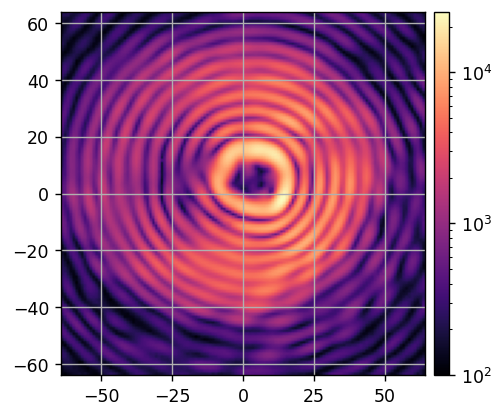

In [75]:
ref_im = scoobi.snap(camlo_stream, 50)
utils.imshow([ref_im], grids=[1], pxscls=[1], norms=[LogNorm()], cmaps=['magma'])

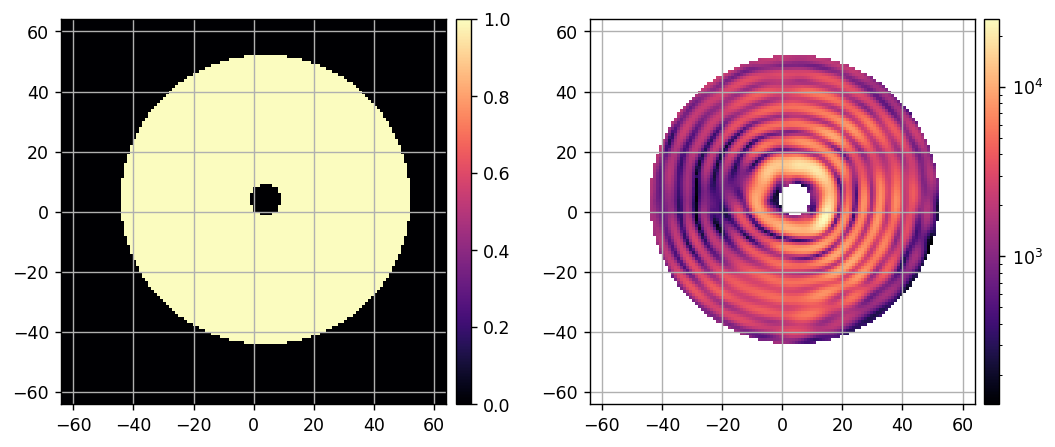

In [77]:
irad = 5
orad = 48
control_mask = llowfsc.create_control_mask(
    camlo_dims, 
    irad, 
    orad, 
    x_shift=-4,
    y_shift=-4,
    even=1,
)
# control_mask = xp.ones((M.nlocam, M.nlocam)).astype(bool)
utils.imshow([control_mask, ref_im * control_mask], grids=[1, 1], pxscls=[1, 1], norms=[None, LogNorm()])

In [78]:
camlo_ref_stream.write(ref_im*control_mask)
utils.save_fits(llowfsc_data_path/'llowfsc_ref_im.fits', ref_im)

Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250415/llowfsc/llowfsc_ref_im.fits


# Calibrate LLOWFSC with the Zernike modes we want to control

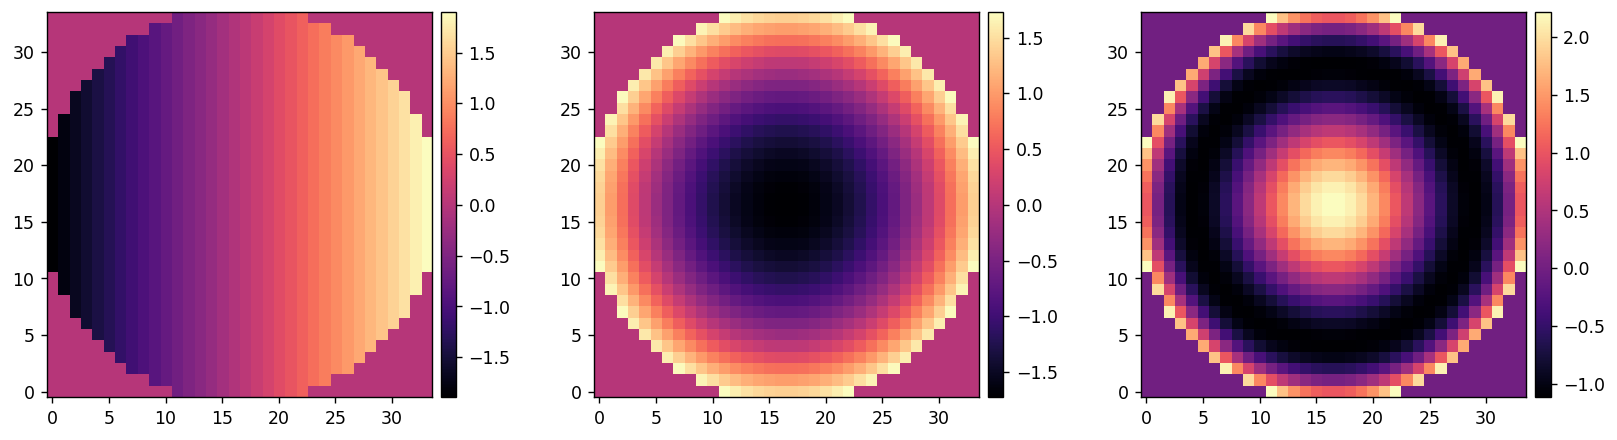

In [79]:
reload(scoobi)
reload(utils)
Nz_modes = 10
zer_modes = ensure_np_array(utils.create_zernike_modes(dm_mask, nmodes=Nz_modes, remove_modes=1))
zer_modal_matrix = zer_modes.reshape(Nz_modes, -1)
utils.imshow([zer_modes[0], zer_modes[2], zer_modes[-1]])

1


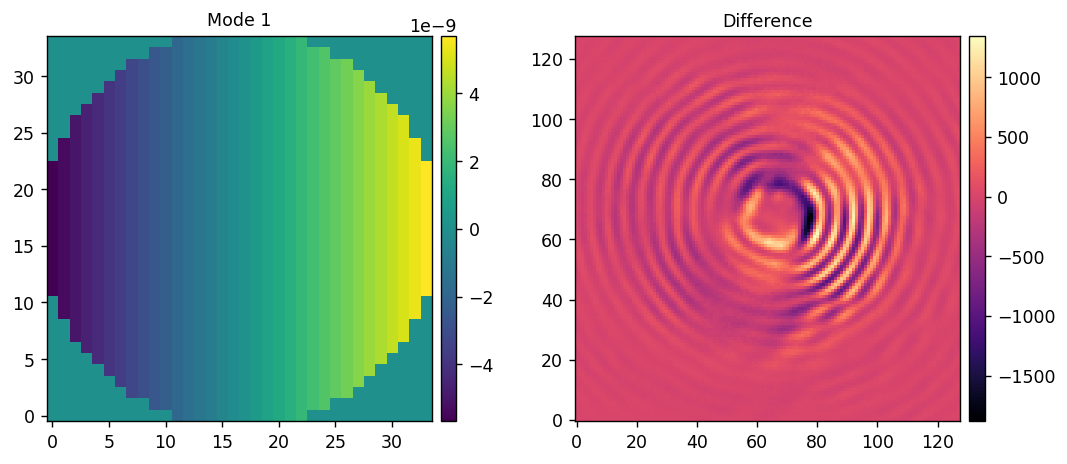

1Calibrated mode 1/10 in 6.997s


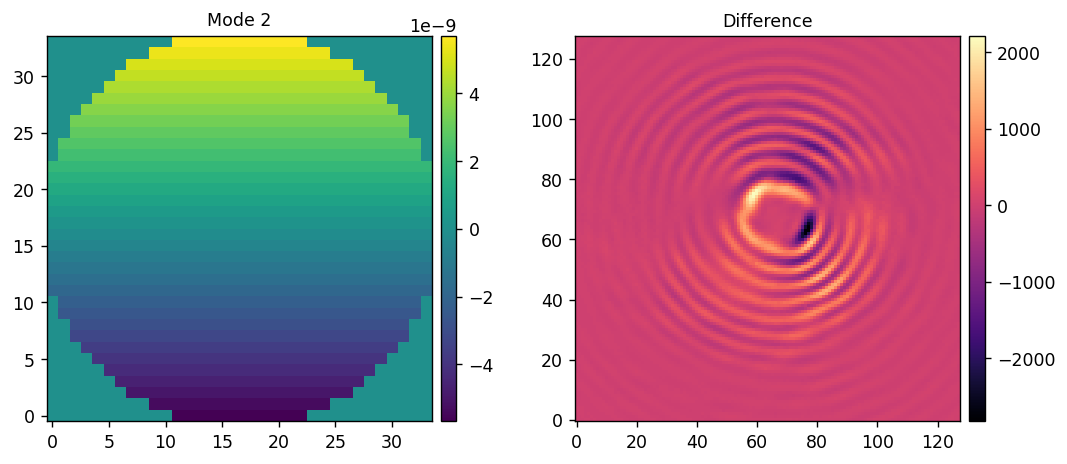

1Calibrated mode 2/10 in 14.066s


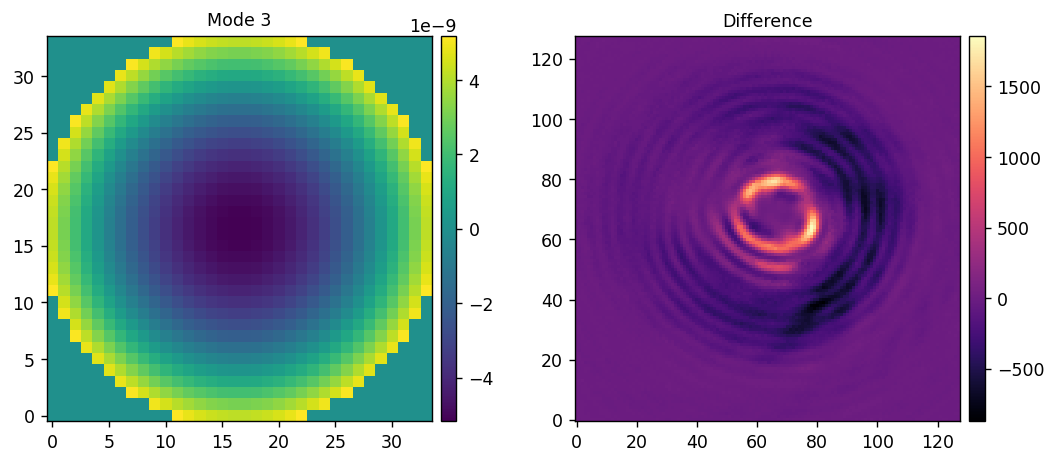

1Calibrated mode 3/10 in 21.579s


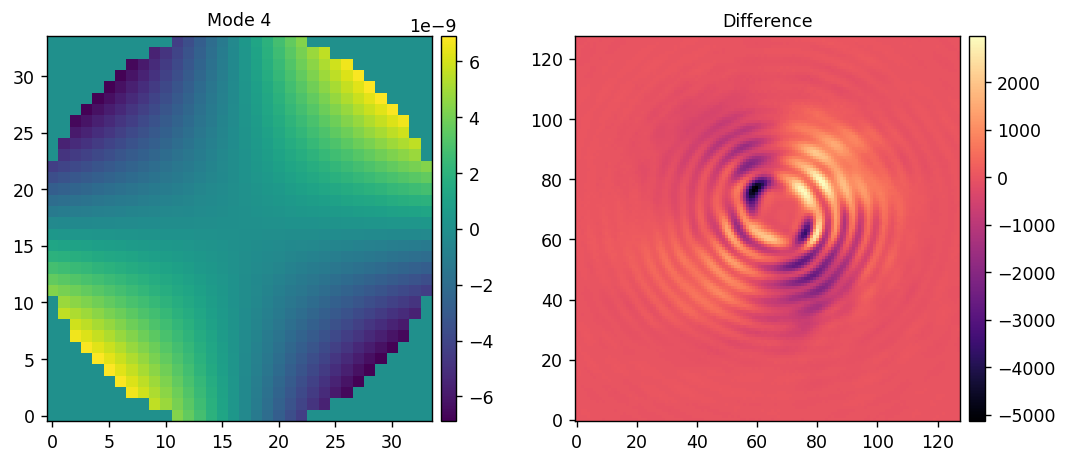

1Calibrated mode 4/10 in 29.278s


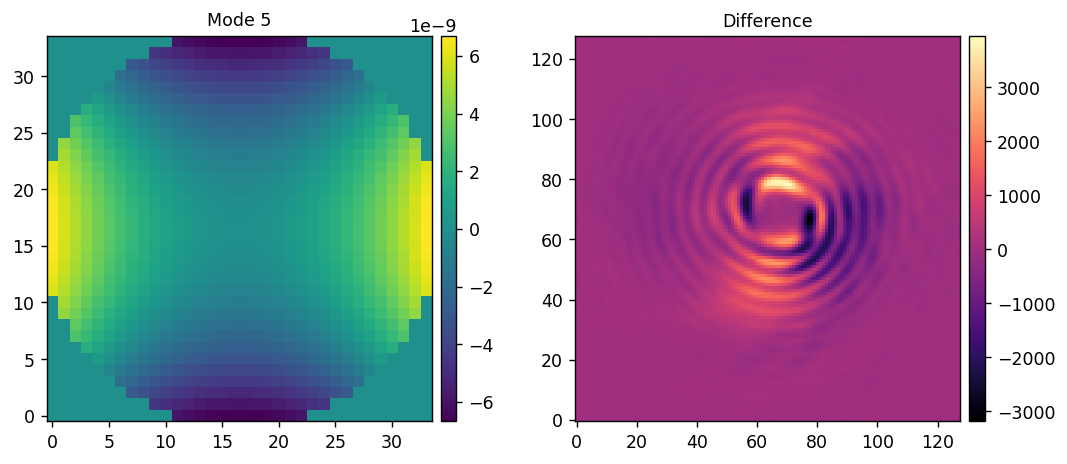

1Calibrated mode 5/10 in 36.978s


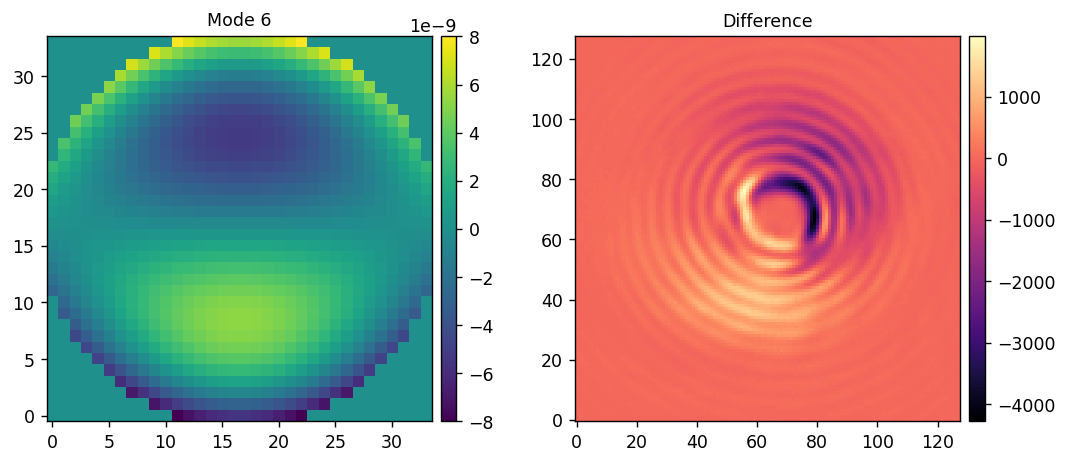

1Calibrated mode 6/10 in 44.548s


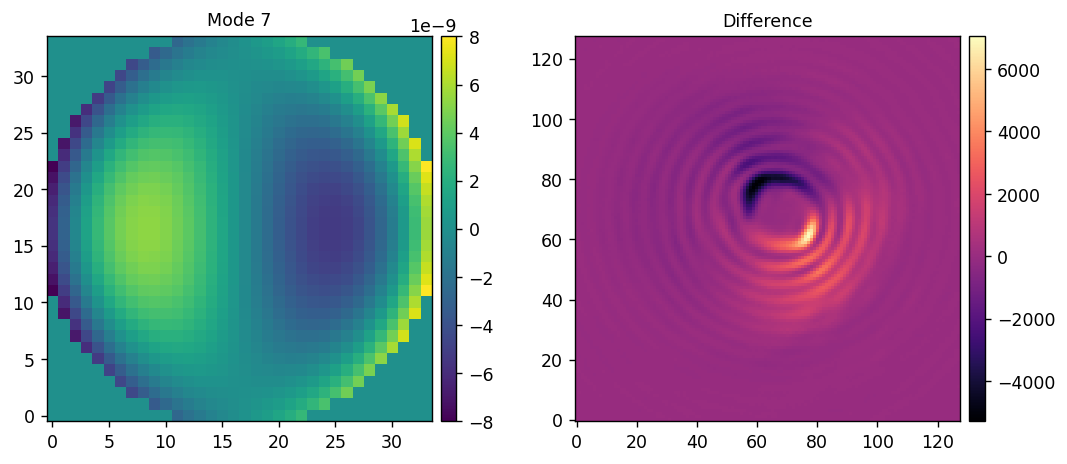

1Calibrated mode 7/10 in 51.745s


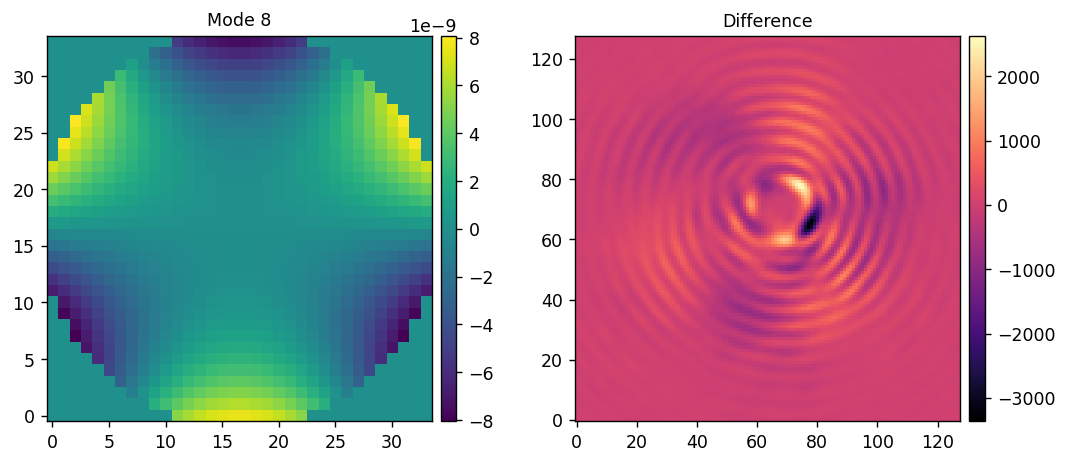

1Calibrated mode 8/10 in 59.500s


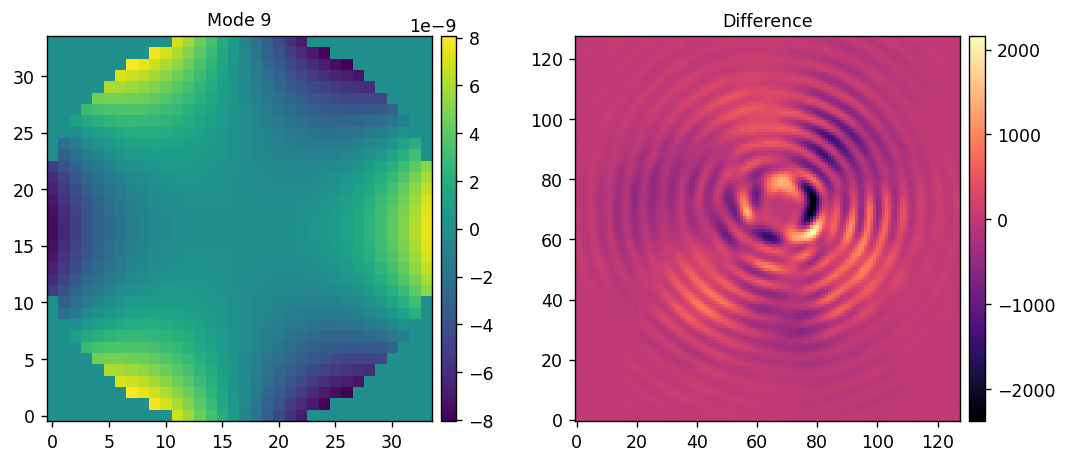

1Calibrated mode 9/10 in 67.081s


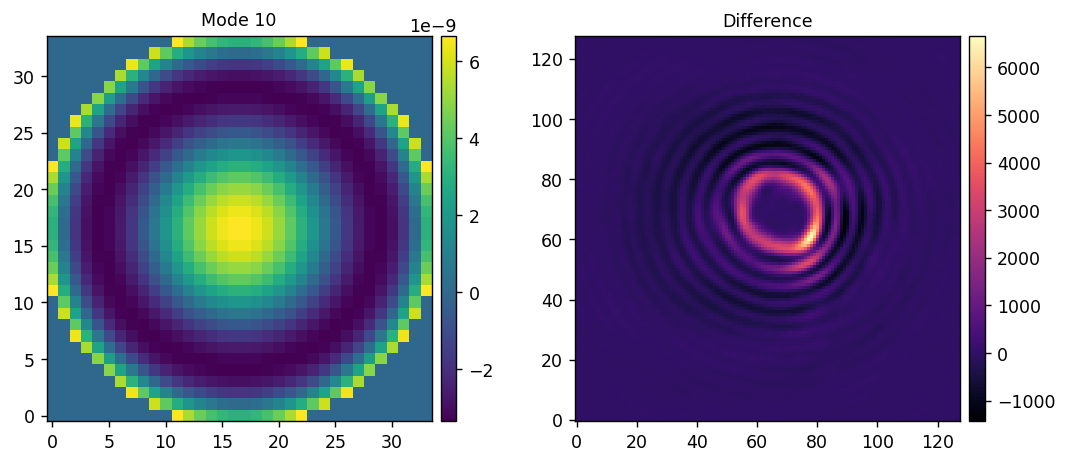

In [ ]:
reload(llowfsc)
zer_calib_amp = 3e-9
zer_calib_nframes = 50

zer_response_matrix, zer_response_cube = llowfsc.calibrate_without_fsm(
    camlo_stream, 
    dm_lo_stream, 
    zer_modes, 
    control_mask, 
    amps=zer_calib_amp, 
    NFRAMES=zer_calib_nframes, 
    dm_delay=0.05, 
    plot=True,
)

In [81]:
zer_calib_data = {
    'response_matrix':zer_response_matrix,
    'response_cube':zer_response_cube,
    'modes':zer_modes, 
    'calib_amp':zer_calib_amp,
    'control_mask':control_mask,
    'NFRAMES':zer_calib_nframes,
    # 'camlo_exp_time':camlo_exp_time,
    # 'camlo_gain':camlo_gain,
}
utils.save_pickle(llowfsc_data_path/'zernike_calibration.pkl', zer_calib_data)

Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250415/llowfsc/zernike_calibration.pkl


In [ ]:
# old_calib_path = data_path/f'exp-'/'llowfsc'/'zernike_calibration.pkl'
# old_calib_data = utils.load_pickle(old_calib_path)

1


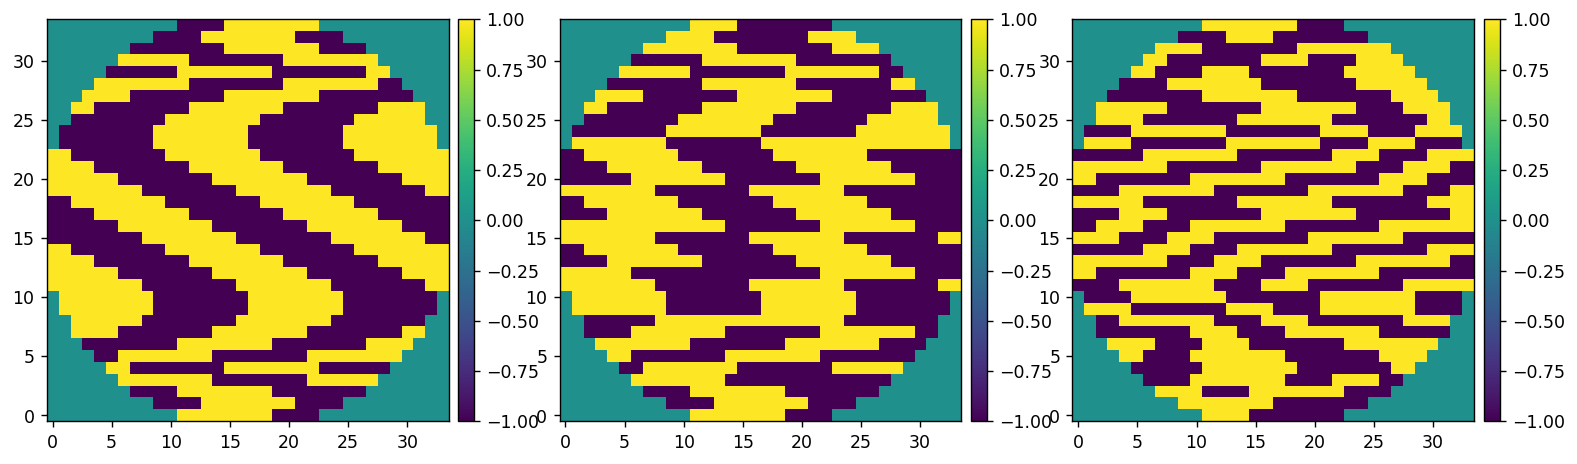

In [ ]:
had_modes = ensure_np_array(utils.create_hadamard_modes(xp.array(dm_mask)))
had_modal_matrix = had_modes.reshape(had_modes.shape[0], -1)
utils.imshow([had_modes[8], had_modes[200], had_modes[300]])

In [16]:
reload(llowfsc)

had_calib_amp = 3e-9
had_calib_nframes = 25

had_response_matrix, had_response_cube = llowfsc.calibrate_without_fsm(
    camlo_stream, 
    dm_lo_stream, 
    had_modes, 
    control_mask, 
    amps=had_calib_amp, 
    NFRAMES=had_calib_nframes, 
    dm_delay=0.02, 
    # plot=True,
)

1


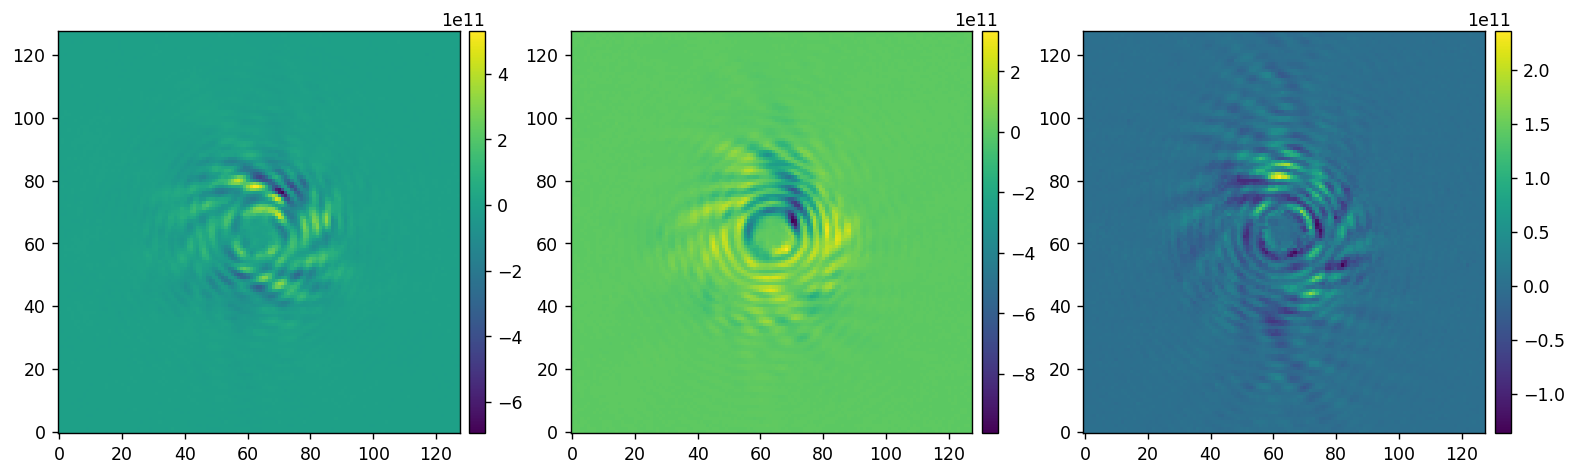

In [ ]:
utils.imshow([had_response_cube[8], had_response_cube[200], had_response_cube[800]])

In [ ]:
had_calib_data = {
    'response_matrix':had_response_matrix,
    'response_cube':had_response_cube,
    'modes':had_modes,
    'calib_amp':had_calib_amp,
    'control_mask':control_mask,
    'NLOCAM':had_calib_nframes,
    # 'camlo_exp_time':camlo_exp_time,
    # 'camlo_gain':camlo_gain,
}
utils.save_pickle(llowfsc_data_path/'hadamard_calibration.pkl', had_calib_data)

Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250321/llowfsc/hadamard_calibration.pkl


# Delete old telemetry data if need to keep data organized. I assume all data has been moved and stored somewhere safe if it was important.

In [105]:
reload(telem)
telem.delete_files(camlo_rawims_path/'*.xrif')
telem.delete_files(camlo_ref_rawims_path/'*.xrif')
telem.delete_files(camlo_ref_offset_rawims_path/'*.xrif')
telem.delete_files(dm_lo_rawims_path/'*.xrif')
telem.delete_files(dm_ho_rawims_path/'*.xrif')

telem.delete_files(llowfsc_telem_path/'*')
telem.delete_files(llowfsc_unpacked_path/'*')

# Define and run the reference offsetting process.

In [ ]:
telem.toggle(1, camlo_ref_offset_name, client0)
telem.toggle(1, dm_ho_name, client0)

In [ ]:
reload(scoobi)
reload(llowfsc)
reload(utils)

update_freq = 200
interval = 1/update_freq

args = [
    had_response_matrix, 
    had_modal_matrix, 
    control_mask, 
    dm_ho_stream, 
    camlo_ref_offset_stream,
]

ref_offset_process = llowfsc.Process(
    interval, 
    llowfsc.update_ref_offset, 
    args, # the args
)

In [21]:
ref_offset_process.start()

In [63]:
ref_offset_process.cancel()

In [32]:
dm_ho_stream.write(0.00 * had_modes[8])

In [ ]:
telem.toggle(0, camlo_ref_offset_name, client0)
telem.toggle(0, dm_ho_name, client0)

# Define and run the LLOWFSC process.

In [100]:
lo_cm = ensure_np_array(utils.TikhonovInverse(xp.array(zer_response_matrix), 0))

gain_channel = 'llowfsc_gains'
leak_channel = 'llowfsc_leakage'
scoobi.create_shmim(gain_channel, (Nz_modes, 1))
scoobi.create_shmim(leak_channel, (1, 1)) # yes, it is a 1x1 array, shmims have to be this way

gains_stream = ImageStream(gain_channel)
leak_stream = ImageStream(leak_channel)
gains_stream.write(np.array([2*[0.75] + 8*[0.25],]))
leak_stream.write(np.array([[0.0]]))

In [103]:
reload(llowfsc)
reload(utils)

llowfsc_freq = 80
llowfsc_interval = 1/llowfsc_freq

args = [
    dm_lo_stream,
    camlo_stream,
    camlo_ref_stream,
    camlo_ref_offset_stream,  
    gains_stream,
    leak_stream, 
    lo_cm, 
    zer_modal_matrix, 
    control_mask, 
]

llowfsc_process = llowfsc.Process(
    1/llowfsc_freq, 
    llowfsc.single_iteration, 
    args, # the args
    # kwargs, # the kwargs
)



# Run the LLOWFSC process

In [106]:
# telem.toggle(1, camlo_name, client0)
telem.toggle(1, dm_lo_name, client0)

In [104]:
llowfsc_process.start()

In [109]:
llowfsc_process.cancel()
time.sleep(0.25)
dm_lo_stream.write(np.zeros(dm_lo_stream.shape))

In [107]:
# telem.toggle(0, camlo_name, client0)
telem.toggle(0, dm_lo_name, client0)

## Adjust leakage and gains

In [58]:
leak_stream.write(np.array([[0.02]]))

In [90]:
gains_stream.write(np.array([2*[0.5] + 8*[0.0]]))

In [91]:
gains_stream.write(np.array([2*[0.5] + 8*[0.05]]))

In [55]:
gains_stream.write(np.array([2*[0.75] + 8*[0.05]]))

In [92]:
gains_stream.write(np.array([2*[0.75] + 3*[0.1] + 5*[0.1]]))

In [ ]:
gains_stream.write(np.array([2*[0.75] + 3*[0.2] + 5*[0.2]]))

# Analyze telemetry data.

In [108]:
telem.move_files(dm_lo_rawims_path, llowfsc_telem_path)

In [ ]:
telem.unpack_data(llowfsc_telem_path, llowfsc_unpacked_path)

In [89]:
dm_lo_fnames = telem.get_fnames(llowfsc_unpacked_path/f'{dm_lo_name}*')
dm_ho_fnames = telem.get_fnames(llowfsc_unpacked_path/f'{dm_ho_name}*')
camlo_ref_offset_fnames = telem.get_fnames(llowfsc_unpacked_path/f'{camlo_ref_offset_name}*')
dm_lo_fnames[-5:], dm_ho_fnames[-5:], camlo_ref_offset_fnames[-5:]

(['/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250415/llowfsc/unpacked-telem/dm00disp02_20250414193359854228754.fits'],
 [],
 [])

In [ ]:
reload(telem)
absolute = 1
dm_lo_times = telem.read_telem_times(dm_lo_fnames, absolute=absolute)
dm_ho_times = telem.read_telem_times(dm_ho_fnames, absolute=absolute)
ref_offset_times = telem.read_telem_times(camlo_ref_offset_fnames, absolute=absolute)
dm_lo_start = dm_lo_times[0]
dm_ho_start = dm_ho_times[0]
ref_offset_start = ref_offset_times[0]

Text(0.5, 1.0, 'dm00disp01 Delta Times: FPS = 500.0087864992362')

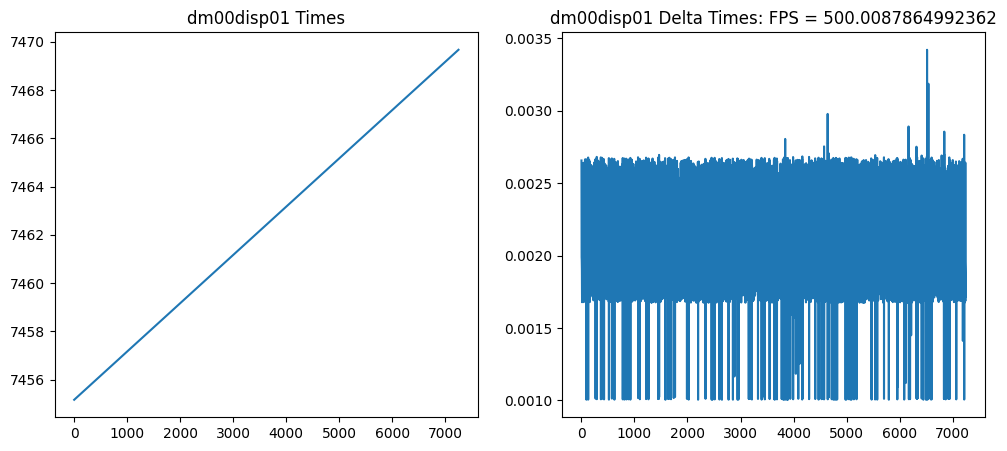

In [ ]:
ref_offset_delTs = ref_offset_times[1:] - ref_offset_times[:-1]
mean_fps = 1/np.mean(ref_offset_delTs)

fig = plt.figure(figsize=(12,5))
plt.subplot(121)
plt.plot(ref_offset_times)
plt.title(f'{camlo_ref_offset_name} Times')

plt.subplot(122)
plt.plot(ref_offset_delTs)
plt.title(f'{camlo_ref_offset_name} Delta Times: FPS = {mean_fps}')

In [ ]:
dm_lo_delTs = dm_lo_times[1:] - dm_lo_times[:-1]
mean_fps = 1/np.mean(dm_lo_delTs)

fig = plt.figure(figsize=(12,5))
plt.subplot(121)
plt.plot(dm_lo_times)
plt.title(f'{dm_lo_name} Times')

plt.subplot(122)
plt.plot(dm_lo_delTs)
plt.title(f'{dm_lo_name} Delta Times: FPS = {mean_fps}')